##Tools

In [ ]:
!pip install -qU Wikipedia
!pip install -qU langchain_community

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [ ]:
!pip install -qU langchain_groq

In [ ]:
!pip install -qU langchain_tools

In [ ]:
!pip install -qU ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 kB 976.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 32.7 MB/s eta 0:00:00


In [ ]:
#1 News Search Tool

from langchain_community.tools import DuckDuckGoSearchRun
search_tool = DuckDuckGoSearchRun()

#2 Wikipedia Search Tool

from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

wikipedia_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())

/tmp/ipykernel_923/3801906948.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [ ]:
wikipedia_tool.invoke("What is the capital of India?")

'Page: Delhi\nSummary: Delhi, officially the National Capital Territory (NCT) of Delhi, is a megacity and a union territory of India containing New Delhi, the capital of India. Straddling the Yamuna river, but spread chiefly to the west, or beyond its right bank, Delhi shares borders with the state of Uttar Pradesh in the east and with the state of Haryana in the remaining directions. Delhi became a union territory on 1 November 1956 and the NCT in 1995. The NCT covers an area of 1,484 square kilometres (573 sq mi). According to the 2011 census, Delhi\'s city proper population was over 11 million, while the NCT\'s population was about 16.8 million.\nThe topography of the medieval fort Purana Qila on the banks of the river Yamuna matches the literary description of the citadel Indraprastha in the Sanskrit epic Mahabharata; however, excavations in the area have revealed no signs of an ancient built environment.\nFrom the early 13th century until the mid-19th century, Delhi was the capita

In [ ]:
from langchain_core.tools import tool

@tool
def enterprise_tool(query:str)->str:
  """This is atool to send emails to employees"""
  return "Email Sent"

In [ ]:
ToolKit = [search_tool,wikipedia_tool,enterprise_tool]

##React Agent

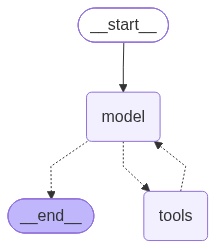

In [ ]:
from langchain.agents import create_agent
from langchain_groq import ChatGroq
import os
from google.colab import userdata
os.environ["GROQ_API_KEY"] =  userdata.get('GROQ_API_KEY')

model = ChatGroq(
    model="qwen/qwen3.8-27b",
    temperature=0.1,
    max_tokens=1000,
    timeout=30
    )

agent = create_agent(model, tools = ToolKit)
agent


##ReAct Agent Invoke With Streams

In [ ]:
query="What are top 5 highest grossing movies of all time"

events= agent.stream(
    {"messages":[("user",query)]},
    stream_mode="values",
)
for event in events:
  event["messages"][-1].pretty_print()

================================ Human Message =================================

What are top 5 highest grossing movies of all time
================================== Ai Message ==================================

Here are the top 5 highest-grossing movies of all time (based on worldwide box office revenue, adjusted for inflation or not, but typically reported in nominal terms):

1. **Avengers: Endgame** (2019) – ~$2.799 billion  
2. **Avatar** (2009) – ~$2.923 billion  
   *(Note: Avatar briefly regained the #1 spot in 2021 after a re-release in China, but Endgame is often listed as #1 in most current rankings due to initial release performance. However, as of 2024, **Avatar** is widely recognized as the all-time highest-grossing film at ~$2.923 billion, with **Avengers: Endgame** at #2.)*

Let me clarify with the most up-to-date consensus:

1. **Avatar** (2009) – ~$2.923 billion  
2. **Avengers: Endgame** (2019) – ~$2.799 billion  
3. **Star Wars: The Force Awakens** (2015) – ~$2.07

##Manually Binding LLM With Tools

In [ ]:
llm_groq= ChatGroq(
    model="qwen/qwen3.8-27b",
    temperature=0.1,
    max_tokens=1000,
    timeout=30
    )

In [ ]:
#Without Binding
llm_groq.invoke("What's latest news about stock market?")

AIMessage(content='As an AI assistant, I do not have access to real-time data, so I cannot provide the specific stock market movements or breaking news for **today**.\n\nHowever, here is how you can get the most accurate and up-to-date information:\n\n1. **Financial News Websites**: Check sources like:\n   - Bloomberg\n   - Reuters\n   - CNBC\n   - Yahoo Finance\n   - The Wall Street Journal\n\n2. **Stock Market Indices**: Look at the current levels of major indices such as:\n   - **S&P 500** (US large-cap)\n   - **Dow Jones Industrial Average** (US blue-chip)\n   - **Nasdaq Composite** (US tech-heavy)\n   - **FTSE 100** (UK)\n   - **Nikkei 225** (Japan)\n   - **Shanghai Composite** (China)\n\n3. **Key Factors to Watch**:\n   - Central bank interest rate decisions (e.g., Federal Reserve, ECB)\n   - Inflation data (CPI, PCE)\n   - Major corporate earnings reports\n   - Geopolitical developments\n   - Employment statistics\n\nFor the latest news, I recommend visiting one of the financial

In [ ]:
#With Binding
llm_binded = llm_groq.bind_tools(ToolKit)
llm_binded.invoke("What's latest news about stock market?")

AIMessage(content='To provide you with the latest news about the stock market, I will search for recent updates.\n\n', additional_kwargs={'tool_calls': [{'id': 'fyvj7xsa2', 'function': {'arguments': '{"query":"latest stock market news today"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 468, 'total_tokens': 520, 'completion_time': 0.131374641, 'completion_tokens_details': None, 'prompt_time': 0.038685928, 'prompt_tokens_details': None, 'queue_time': 0.005309535, 'total_time': 0.170060569}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_57c7e760a9', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0c37f-ce44-71a2-97c5-cdcf939f612d-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'latest stock market news today'}, 'id': 'fyvj7xsa2', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_toke